# Description of the dataset: Diabetes-MIMIC IV

The dataset used in this study is a subset of the MIMIC-IV (Medical Information Mart for Intensive Care), a large deidentified dataset of patients admitted to Beth  Israel Deaconess Medical Center in Boston between 2008 - 2022. The subset focusses on patients with diabetic diagnoses. The criteria for selecting the subjects were the following:
- Patients diagnosed with diabetes.
- Subjects aged < 18 years old were excluded.
- Data from each patient’s first ICU admission

These criterias were included tring to replicate the dataset used in the paper "Machine learning prediction models and nomogram to predict the risk ofin-hospital death for severe DKA: A clinical study based on MIMIC-IV, eICUdatabases, and a college hospital ICU" (https://www.sciencedirect.com/science/article/pii/S1386505623000679), with some modifications.

The features included are: 
Demographic: 
- race 
- sex
- age
- weight
- admission 
- emergency 
- insurance

Comorbidities: 
- acute kidney injury
- chronic kidney disease
- diabetes (chronic complication or without)
- cardiac disease
- hypertension
- chronic obstructive pulmonary disease

Laboratory results from the first ICU stay and 24h before and after it, the initial values, the lowest and highest levels of:
- blood PH
- calcium
- creatinine
- hemoglobin
- WBC (white blood cells)
- lactate
- platelets
- potassium
- sodium
- glucose
- chloride
- plasma osmolality (2*sodium + glucose + blood urea nitrogen)
- BUN (blood urea nitrogen)

Vital signs in the ICU:
- highest and initial values levels of heart rate
- MAP (mean arterial pressure)
- respiratory rate
- first-day urineoutput

Medicine scores: 
- APS III score
- SOFA score
- GCS score (first gcs total)
- CNS score
- Renal score

Interventions in medicine:
- ventilation
- nitrate pune (nitroprusside ?)
- vasopressor-> (noradrenaline, phenylephrine, epinephrine, dopamine, and dobutamine)
- albumin


## Data Extraction
The dataset was extracted using a SQL query from the *mimiciv_3_1_hosp* dataset, using the following query: 
``` mysql

```


In [213]:
import os 
from google.cloud import bigquery
import pandas as pd

In [237]:
SERVICE_ACCOUNT_JSON = "um-thesis-021adda120c0.json"
client = bigquery.Client.from_service_account_json(SERVICE_ACCOUNT_JSON)

In [238]:
query = """
SELECT * 
FROM `um-thesis.cohort_diabetes.icu_diabetes_dataset`
"""
df = client.query(query).to_dataframe()

## Dataset Structure and Size

The dataset contains 20283 entries, representing laboratory test results for unique patients with diabetic diagnosis in their firt icu admission. The data includes 79 columns with a mix of categorical and numerical variables. 

In [239]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20283 entries, 0 to 20282
Data columns (total 79 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   subject_id           20283 non-null  Int64         
 1   hadm_id              20283 non-null  Int64         
 2   stay_id              20283 non-null  Int64         
 3   icu_intime           20283 non-null  datetime64[us]
 4   admittime            20283 non-null  datetime64[us]
 5   dischtime            20283 non-null  datetime64[us]
 6   admission_type       20283 non-null  object        
 7   insurance            20059 non-null  object        
 8   race                 20283 non-null  object        
 9   gender               20283 non-null  object        
 10  age                  20283 non-null  Int64         
 11  weight               19837 non-null  float64       
 12  all_icd_codes        20283 non-null  object        
 13  admission_count      20283 non-

In [119]:
df.describe(include='all')

,subject_id,hadm_id,stay_id,icu_intime,admittime,dischtime,admission_type,insurance,race,gender,...,apsiii_prob,sofa,cns,renal,gcs,ventilation,nitroprusside,vasopressor,albumin,mortality
count,20283.0,20283.0,20283.0,20283,20283,20283,20283,20059,20283,20283,...,20283.000000,20283.0,20195.0,20250.0,20200.000000,20283.0,20283.0,20283.0,20283.0,20283.0
unique,<NA>,<NA>,<NA>,NaN,NaN,NaN,9,5,33,2,...,NaN,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>
top,<NA>,<NA>,<NA>,NaN,NaN,NaN,EW EMER.,Medicare,WHITE,M,...,NaN,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>
freq,<NA>,<NA>,<NA>,NaN,NaN,NaN,9827,12372,11600,11850,...,NaN,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>
mean,14992795.427304,24968165.741951,34961156.86782,2153-09-13 04:08:34.981758,2153-09-11 22:02:24.333679,2153-09-22 12:25:20.411182,NaN,NaN,NaN,NaN,...,0.122910,4.63319,0.666205,1.080889,14.321089,0.383375,0.008036,0.335503,0.157817,0.397574
min,10000980.0,20000094.0,30000831.0,2110-01-16 04:28:00,2110-01-13 19:14:00,2110-01-22 16:23:00,NaN,NaN,NaN,NaN,...,0.013463,0.0,0.0,0.0,3.000000,0.0,0.0,0.0,0.0,0.0
25%,12488859.0,22470115.0,32452494.5,2133-10-07 06:13:19,2133-10-06 03:48:30,2133-10-17 16:15:00,NaN,NaN,NaN,NaN,...,0.050995,2.0,0.0,0.0,15.000000,0.0,0.0,0.0,0.0,0.0
50%,15006483.0,24940189.0,34947121.0,2153-11-12 12:45:31,2153-11-11 12:07:00,2153-11-22 19:24:00,NaN,NaN,NaN,NaN,...,0.079360,4.0,0.0,1.0,15.000000,0.0,0.0,0.0,0.0,0.0
75%,17513318.0,27463521.0,37452528.0,2173-07-29 13:38:12.500000,2173-07-29 08:33:00,2173-08-09 01:53:00,NaN,NaN,NaN,NaN,...,0.137442,6.0,1.0,2.0,15.000000,1.0,0.0,1.0,0.0,1.0
max,19999828.0,29999828.0,39999858.0,2213-10-02 07:37:35,2213-10-02 07:36:00,2213-10-14 11:04:00,NaN,NaN,NaN,NaN,...,0.969422,23.0,4.0,4.0,15.000000,1.0,1.0,1.0,1.0,1.0


In [120]:
df.head()

,subject_id,hadm_id,stay_id,icu_intime,admittime,dischtime,admission_type,insurance,race,gender,...,apsiii_prob,sofa,cns,renal,gcs,ventilation,nitroprusside,vasopressor,albumin,mortality
0,10000980,26913865,39765666,2189-06-27 08:42:00,2189-06-27 07:38:00,2189-07-03 03:00:00,EW EMER.,Medicare,BLACK/AFRICAN AMERICAN,F,...,0.050995,2,0,2,15.0,1,0,0,0,1
1,10001843,26133978,39698942,2134-12-05 18:50:03,2134-12-05 00:10:00,2134-12-06 12:54:00,URGENT,Medicare,WHITE,M,...,0.454476,9,1,3,13.0,0,0,0,0,1
2,10002013,23581541,39060235,2160-05-18 10:00:53,2160-05-18 07:45:00,2160-05-23 13:30:00,SURGICAL SAME DAY ADMISSION,Medicare,OTHER,F,...,0.044555,4,0,0,15.0,1,0,1,1,0
3,10002443,21329021,35044219,2183-10-18 00:47:00,2183-10-17 23:20:00,2183-10-20 18:47:00,EW EMER.,Private,WHITE,M,...,0.075975,3,0,0,15.0,0,0,0,0,0
4,10002495,24982426,36753294,2141-05-22 20:18:01,2141-05-22 20:17:00,2141-05-29 17:41:00,URGENT,Medicare,UNKNOWN,M,...,0.131935,3,0,1,15.0,1,0,1,0,0


### Missing Values
The missing values of enrolled individuals in MIMIC-IV were all filled with multiple imputations by chained equations (MICE) before the data splitting, separately.



In [240]:
# Missing values
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
pc_missing = df.isnull().mean() * 100
pc_missing = pc_missing[pc_missing > 0].sort_values(ascending=False)

In [122]:
missing

ph_max                5831
ph_initial            5831
ph_min                5831
lactate_min           5754
lactate_initial       5754
lactate_max           5754
urineoutput            837
calcium_min            812
calcium_initial        812
calcium_max            812
weight                 446
insurance              224
hemoglobin_initial     189
hemoglobin_min         189
hemoglobin_max         189
platelet_max           187
platelet_min           187
platelet_initial       187
wbc_initial            186
wbc_min                186
wbc_max                186
osmolality_initial     172
osmolality_min         172
osmolality_max         172
glucose_max            168
glucose_initial        168
glucose_min            168
chloride_initial       166
chloride_min           166
chloride_max           166
potassium_initial      166
potassium_max          166
potassium_min          166
sodium_initial         165
sodium_min             165
sodium_max             165
bun_initial            162
b

MISSING VALUES 
Before:
- use only the icd-codes
- add data from 24h before and after the icu stay

chloride_initial             13885
chloride_min                 13885
chloride_max                 13885
initial_mbp                  12405
calcium_initial              10064
calcium_max                  10064
calcium_min                  10064
ph_initial                    5918
ph_min                        5918
ph_max                        5918
lactate_min                   5846
lactate_max                   5846
lactate_initial               5846
urineoutput                    875
weight                         468
insurance                      249
wbc_max                        182
platelet_min                   182
platelet_max                   182
platelet_initial               182
hemoglobin_initial             182
wbc_min                        182
wbc_initial                    182
hemoglobin_max                 182
hemoglobin_min                 182
plasma_osmolality_initial      163
plasma_osmolality_min          163
plasma_osmolality_max          163
sodium_max                     160
glucose_max                    160
glucose_min                    160
glucose_initial                160
potassium_initial              160
sodium_min                     160
sodium_initial                 160
potassium_max                  160
potassium_min                  160
bun_initial                    155
bun_min                        155
bun_max                        155
creatinine_max                 153
creatinine_min                 153
creatinine_initial             153
cns                             97
gcs                             89
resp_rate_max                   54
mbp_max                         45
heart_rate_max                  34
renal                           34
initial_resp_rate               23
initial_heart_rate               7
cardiac_disease                  3
ckd                              3
aki                              3
copd                             3
hypertension                     3
dtype: int64

In [241]:
pc_missing

ph_max                28.748213
ph_initial            28.748213
ph_min                28.748213
lactate_min           28.368585
lactate_initial       28.368585
lactate_max           28.368585
urineoutput            4.126608
calcium_min            4.003353
calcium_initial        4.003353
calcium_max            4.003353
weight                 2.198886
insurance              1.104373
hemoglobin_initial     0.931815
hemoglobin_min         0.931815
hemoglobin_max         0.931815
platelet_max           0.921954
platelet_min           0.921954
platelet_initial       0.921954
wbc_initial            0.917024
wbc_min                0.917024
wbc_max                0.917024
osmolality_initial     0.848001
osmolality_min         0.848001
osmolality_max         0.848001
glucose_max            0.828280
glucose_initial        0.828280
glucose_min            0.828280
chloride_initial       0.818419
chloride_min           0.818419
chloride_max           0.818419
potassium_initial      0.818419
potassiu

In [124]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set(style="whitegrid")

In [127]:
missing_cols = pc_missing[pc_missing > 15].index.tolist()

In [128]:
missing_cols

['ph_max',
 'ph_initial',
 'ph_min',
 'lactate_min',
 'lactate_initial',
 'lactate_max']

In [129]:
patients_with_missing = df[df[missing_cols].isnull().any(axis=1)].copy()

In [130]:
len(patients_with_missing)

6942

In [131]:
 # Count how many of the 7 columns are missing per row
patients_with_missing['num_missing'] = patients_with_missing[missing_cols].isnull().sum(axis=1)

# Count how many patients fall into each group (0 to 7 missing values)
missing_distribution = patients_with_missing['num_missing'].value_counts().sort_index()

# Display the distribution
print(missing_distribution)
print((missing_distribution / len(df) * 100).round(2))


num_missing
3    2299
6    4643
Name: count, dtype: int64
num_missing
3    11.33
6    22.89
Name: count, dtype: float64


In [132]:
for col in missing_cols: 
    df[f'has_{col}'] = df[col].notnull().astype(int)

    # Group by this indicator
    summary = df.groupby(f'has_{col}').agg(
        total=('subject_id', 'count'),
        avg_age=('age', 'mean'),
        mortality_rate=('mortality', 'mean'),
        avg_sofa=('sofa', 'mean'),
        avg_apsiii=('apsiii', 'mean')
    ).reset_index()

    summary[f'has_{col}'] = summary[f'has_{col}'].map({0: 'Missing', 1: 'Present'})
    print(f"\n📋 Summary by {col} Availability:")
    print(summary)



📋 Summary by ph_max Availability:
  has_ph_max  total    avg_age  mortality_rate  avg_sofa  avg_apsiii
0    Missing   5831  68.559767        0.372492  2.792831   38.083519
1    Present  14452  67.470592        0.407694  5.375727   48.517921

📋 Summary by ph_initial Availability:
  has_ph_initial  total    avg_age  mortality_rate  avg_sofa  avg_apsiii
0        Missing   5831  68.559767        0.372492  2.792831   38.083519
1        Present  14452  67.470592        0.407694  5.375727   48.517921

📋 Summary by ph_min Availability:
  has_ph_min  total    avg_age  mortality_rate  avg_sofa  avg_apsiii
0    Missing   5831  68.559767        0.372492  2.792831   38.083519
1    Present  14452  67.470592        0.407694  5.375727   48.517921

📋 Summary by lactate_min Availability:
  has_lactate_min  total    avg_age  mortality_rate  avg_sofa  avg_apsiii
0         Missing   5754  67.998783        0.357664  2.777372   37.719152
1         Present  14529  67.698534         0.41338   5.36816   48.606

In [133]:
# Create ICU LOS column (in days)
df['icu_los_days'] = (df['dischtime'] - df['icu_intime']).dt.total_seconds() / (24 * 3600)
los_results = []

for var in missing_cols:
    temp = df.copy()
    temp['is_missing'] = temp[var].isna()
    summary = temp.groupby('is_missing')['icu_los_days'].agg(
        count='count',
        avg_los='mean',
        median_los='median'
    ).reset_index()
    summary['feature'] = var
    los_results.append(summary)

# Combine all results
los_df = pd.concat(los_results)
los_df['is_missing'] = los_df['is_missing'].map({True: 'Missing', False: 'Present'})

# Reorder columns
los_df = los_df[['feature', 'is_missing', 'count', 'avg_los', 'median_los']]

los_df = los_df.sort_values(by=['feature', 'is_missing'])

print(los_df)


           feature is_missing  count    avg_los  median_los
1  lactate_initial    Missing   5754   5.993695    4.470307
0  lactate_initial    Present  14529  10.672194    7.012222
1      lactate_max    Missing   5754   5.993695    4.470307
0      lactate_max    Present  14529  10.672194    7.012222
1      lactate_min    Missing   5754   5.993695    4.470307
0      lactate_min    Present  14529  10.672194    7.012222
1       ph_initial    Missing   5831   5.882993    4.433333
0       ph_initial    Present  14452  10.741787    7.050521
1           ph_max    Missing   5831   5.882993    4.433333
0           ph_max    Present  14452  10.741787    7.050521
1           ph_min    Missing   5831   5.882993    4.433333
0           ph_min    Present  14452  10.741787    7.050521


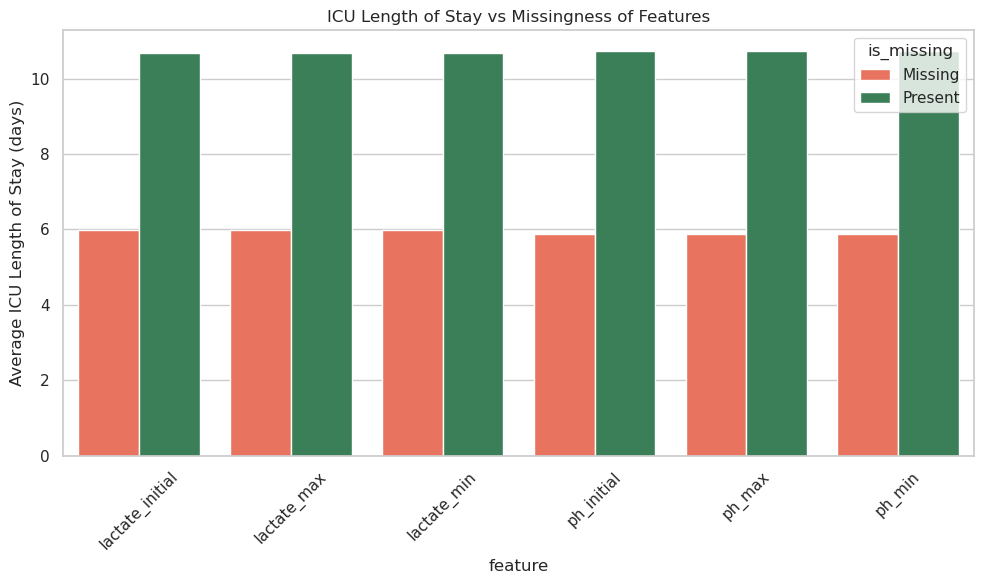

In [134]:
df_los_summary = pd.DataFrame(los_df)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_los_summary, 
    x="feature", 
    y="avg_los", 
    hue="is_missing",
    palette={"Missing": "tomato", "Present": "seagreen"}
)
plt.xticks(rotation=45)
plt.ylabel("Average ICU Length of Stay (days)")
plt.title("ICU Length of Stay vs Missingness of Features")
plt.tight_layout()
plt.show()

In [286]:
import pandas as pd

missing_feature = df[df['ph_max'].isnull()].copy()

missing_feature['all_icd_codes'] = missing_feature['all_icd_codes'].str.split(',')

exploded_icds = missing_feature.explode('all_icd_codes')

icd_freq = exploded_icds['all_icd_codes'].value_counts().reset_index()
icd_freq.columns = ['ICD_code', 'count']

print("top 10 ICD codes among patients with missing chloride:")
print(icd_freq.head(20))


top 10 ICD codes among patients with missing chloride:
   ICD_code  count
0     25000   2995
1      4019   2630
2      E785   2501
3      2724   2370
4      E119   2052
5       I10   2001
6      5849   1578
7      Z794   1489
8    Z87891   1460
9     V5867   1448
10     N179   1406
11     4280   1387
12    41401   1385
13     K219   1335
14    I2510   1328
15    53081   1325
16     2859   1183
17    42731   1120
18    E1122   1113
19    40390   1104


In [290]:
print(df.dropna(subset=['lactate_initial', 'lactate_max', 'lactate_min', 'ph_initial', 'ph_max', 'ph_min']).shape)


(13341, 79)


In [291]:
categorical_vars = ['gender', 'race', 'admission_type', 'insurance', 'long_title']
for col in categorical_vars:
    if col in df.columns:
        print(f"\n{col}:\n", df[col].value_counts(dropna=False))


gender:
 gender
M    11850
F     8433
Name: count, dtype: int64

race:
 race
WHITE                                        11600
BLACK/AFRICAN AMERICAN                        2428
UNKNOWN                                       1919
OTHER                                          773
WHITE - OTHER EUROPEAN                         424
UNABLE TO OBTAIN                               422
HISPANIC/LATINO - PUERTO RICAN                 338
ASIAN - CHINESE                                255
ASIAN                                          233
WHITE - RUSSIAN                                231
HISPANIC OR LATINO                             226
HISPANIC/LATINO - DOMINICAN                    219
BLACK/CARIBBEAN ISLAND                         197
BLACK/CAPE VERDEAN                             143
PATIENT DECLINED TO ANSWER                     127
BLACK/AFRICAN                                  108
ASIAN - SOUTH EAST ASIAN                        90
PORTUGUESE                                      78
ASIA

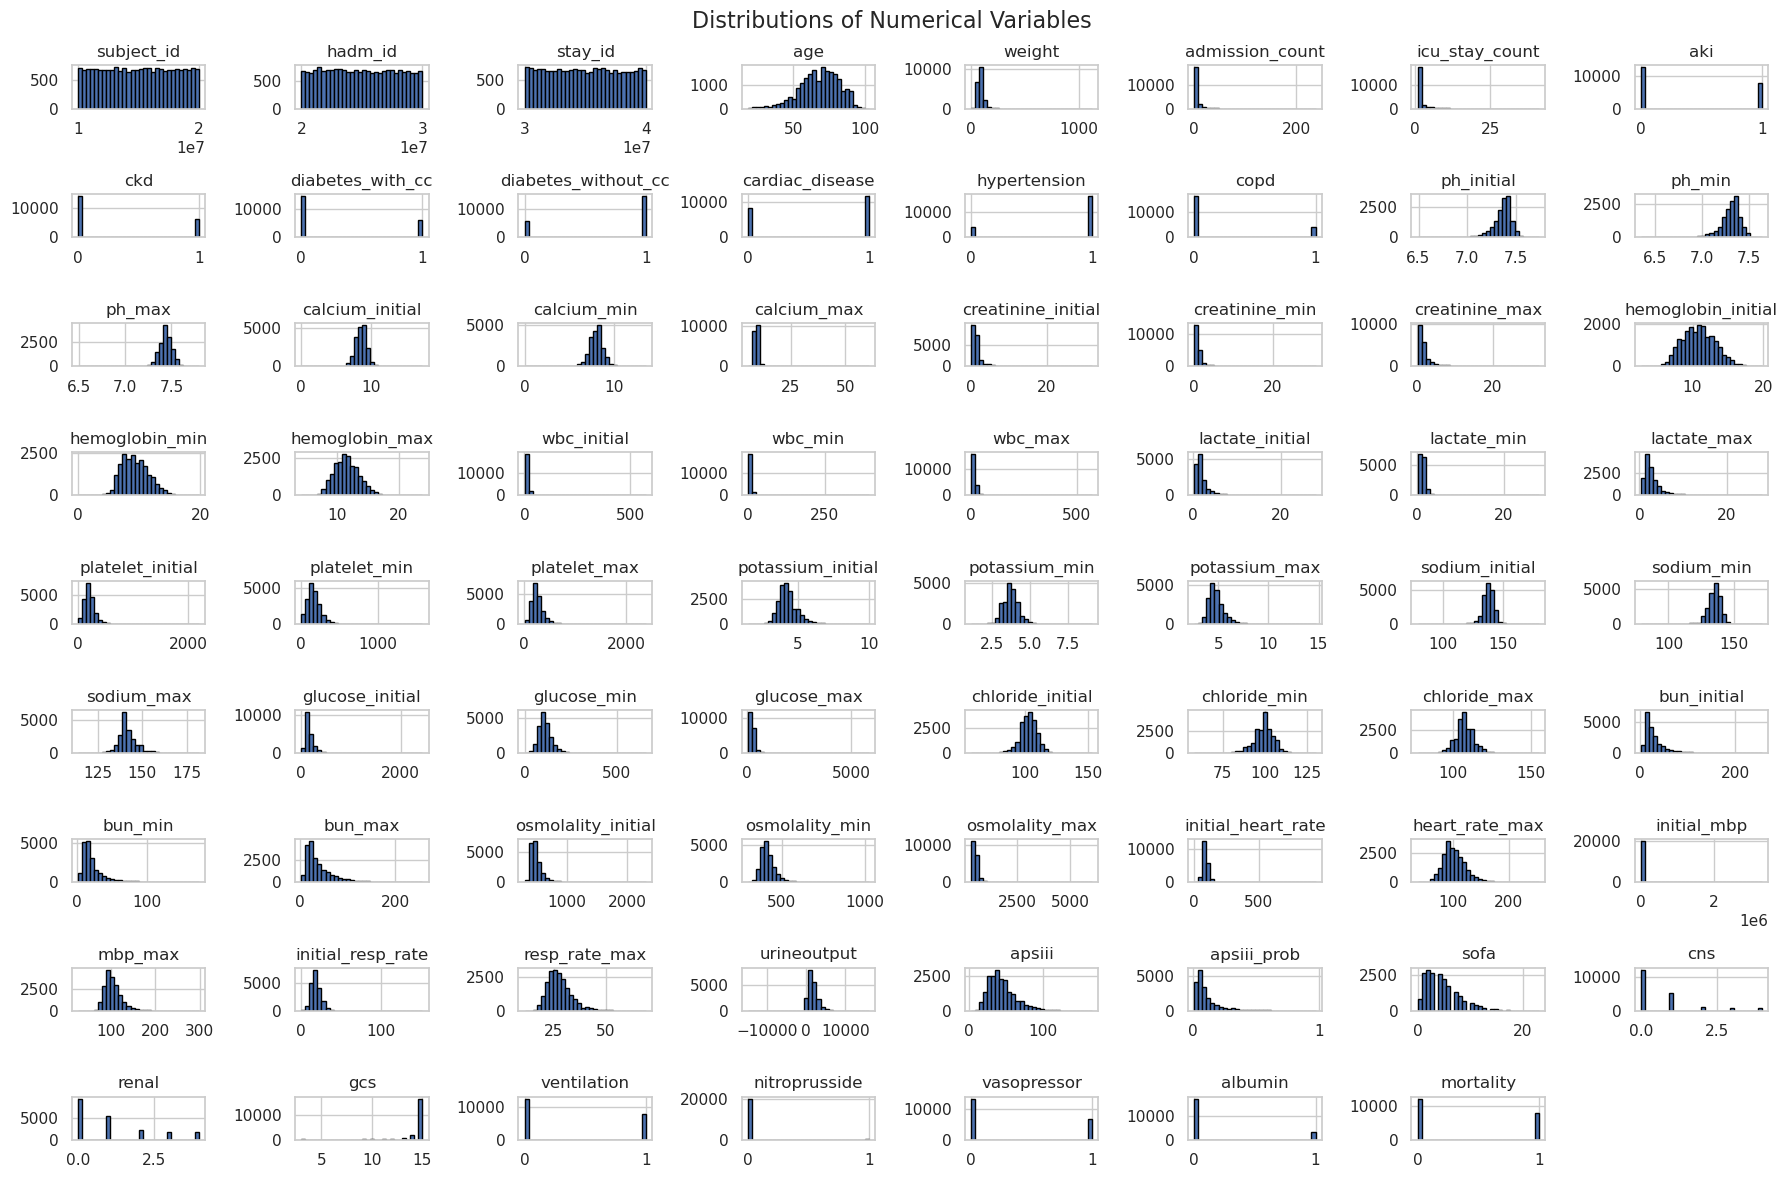

In [292]:
import matplotlib.pyplot as plt
# Histograms for numerical features
numeric_vars = df.select_dtypes(include='number').columns.tolist()
df[numeric_vars].hist(figsize=(18, 12), bins=30, edgecolor='black')
plt.suptitle("Distributions of Numerical Variables", fontsize=16)
plt.tight_layout()
plt.show()

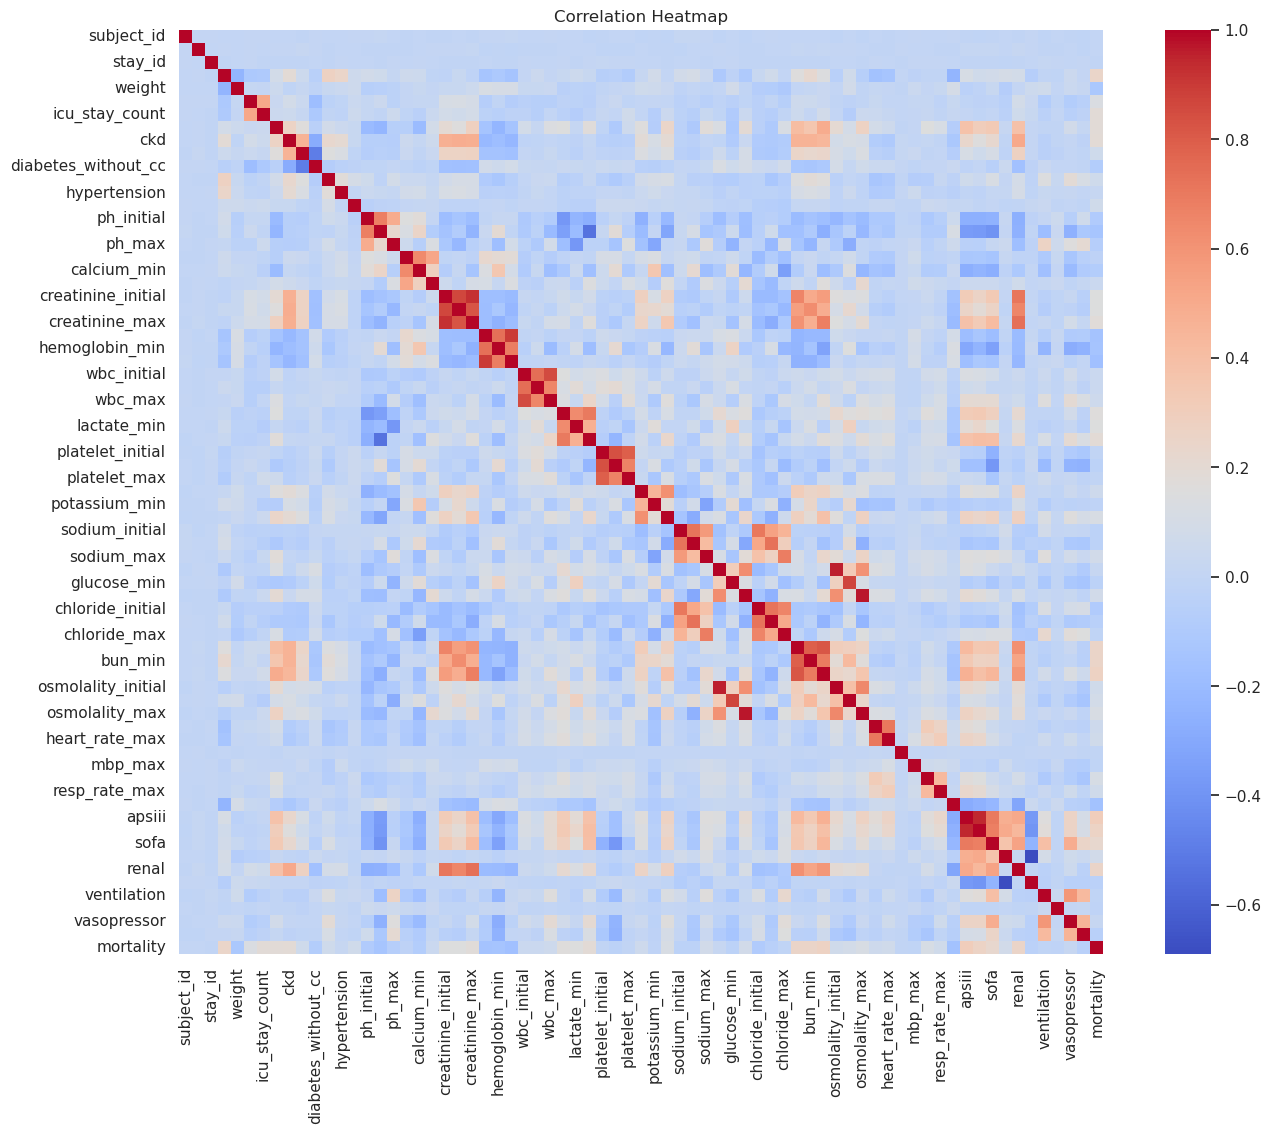

mortality      1.000000
apsiii         0.302598
bun_max        0.267558
apsiii_prob    0.261440
renal          0.253475
bun_min        0.250875
bun_initial    0.247728
age            0.243183
sofa           0.225622
lactate_max    0.192100
Name: mortality, dtype: float64


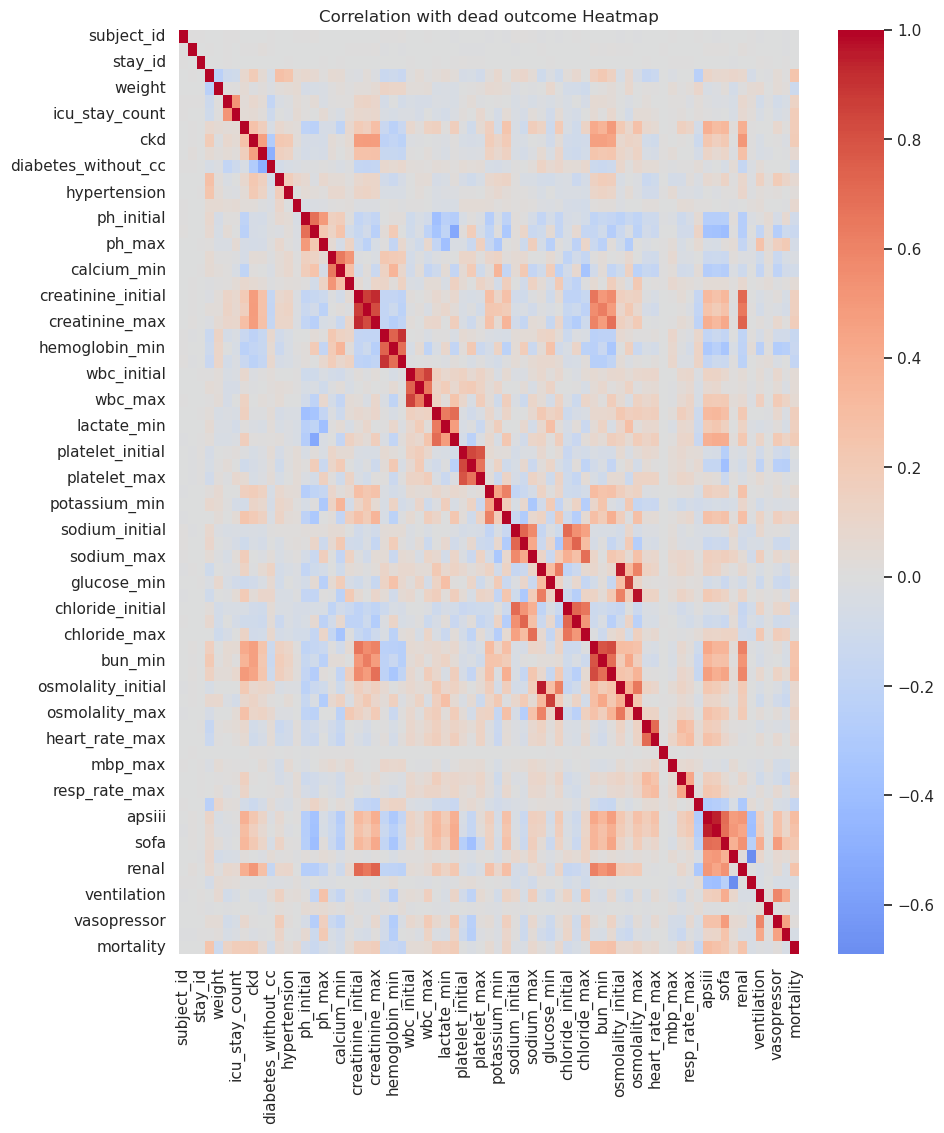

In [293]:
plt.figure(figsize=(16, 12))
sns.heatmap(df[numeric_vars].corr(), cmap='coolwarm', annot=False, fmt=".2f", square=True)
plt.title("Correlation Heatmap")
plt.show()

correlation = df.corr(numeric_only=True)['mortality'].sort_values(ascending=False)
print(correlation.head(10))

plt.figure(figsize=(10, 12))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm', center=0)
plt.title('Correlation with dead outcome Heatmap')
plt.show()


## Exploratory Data Analysis


### Distribution of age

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


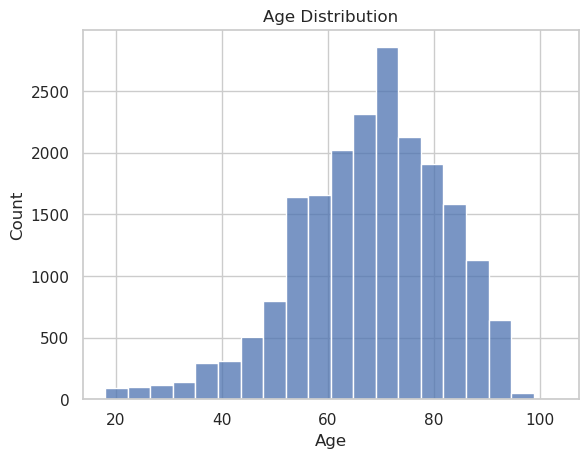

In [146]:
# sns.histplot(df.drop_duplicates(subset="subject_id")['age'].dropna().astype(int), bins=20)
sns.histplot(df['age'].dropna().astype(int).to_numpy(), bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.show()


### Gender balance

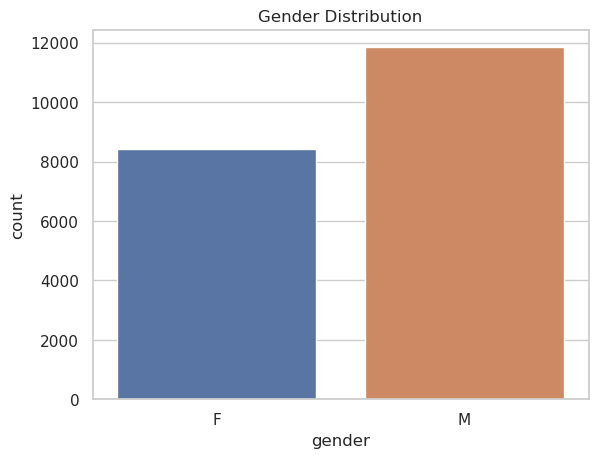

In [147]:
sns.countplot(data=df, x='gender')
plt.title("Gender Distribution")
plt.show()


### Distribution of the weight

Outlier the weight?

Maximum weight after filtering (<= 200): 200.0
Number of weights above 250: 11
Values above 200: [ 230.  1120.   205.   247.7  202.   227.3  236.4  254.   221.   212.
  273.5  225.   237.   211.8  219.   211.   218.2  237.   204.   223.
  201.   203.   202.   204.   203.   219.3  200.2  201.   296.8  216.
  245.   272.   202.4  201.   218.   227.   226.   224.   209.   207.
  274.8  204.5  238.6  225.   281.8  268.   220.   212.3  254.   225.
  224.   710.   215.   202.2  202.   212.3  204.   227.   886.   229.
  219.1  212. ]


/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


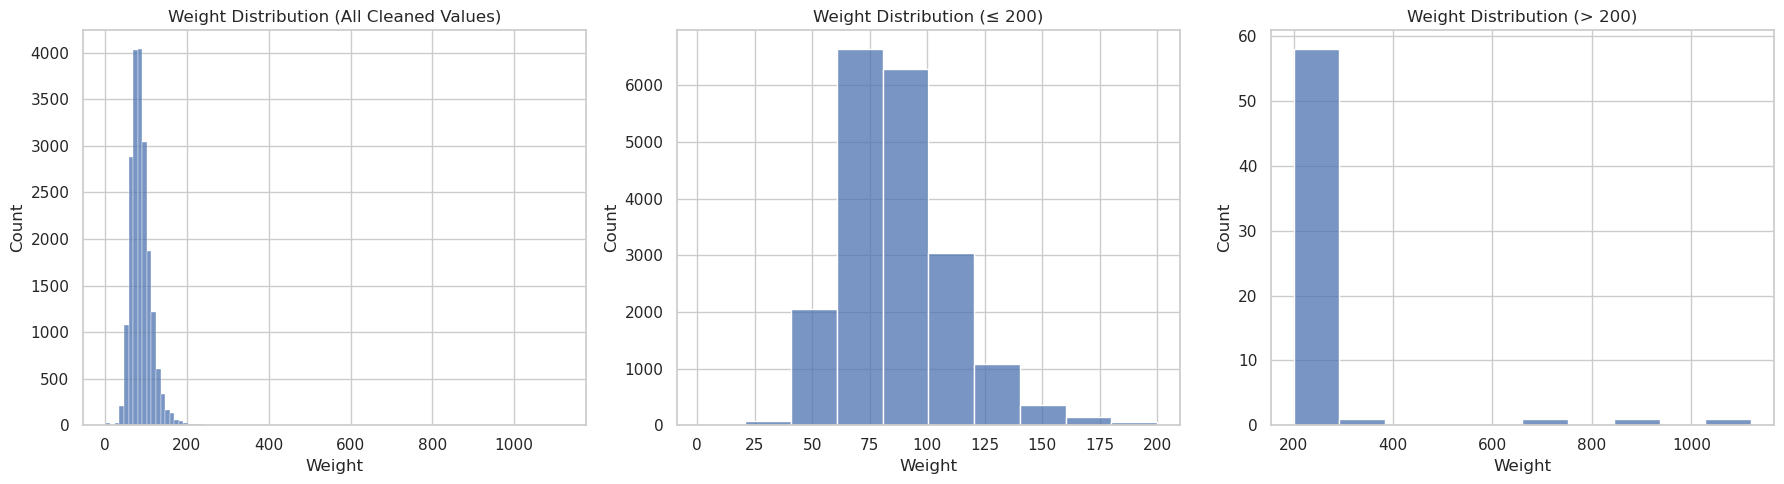

In [177]:
weights = df['weight'].replace([np.inf, -np.inf], np.nan).dropna()

weights_less_200 = weights[weights <= 200].to_numpy()
weights_more_200 = weights[weights > 200].to_numpy()

max_weight = weights_less_200.max() if len(weights_less_200) > 0 else np.nan
print(f"Maximum weight after filtering (<= 200): {max_weight}")
print(f"Number of weights above 250: {(weights > 250).sum()}")
print(f"Values above 200: {weights_more_200}")

fig, axs = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(weights.to_numpy(), bins=100, ax=axs[0])
axs[0].set_title("Weight Distribution (All Cleaned Values)")
axs[0].set_xlabel("Weight")

sns.histplot(weights_less_200, bins=10, ax=axs[1])
axs[1].set_title("Weight Distribution (≤ 200)")
axs[1].set_xlabel("Weight")

sns.histplot(weights_more_200, bins=10, ax=axs[2])
axs[2].set_title("Weight Distribution (> 200)")
axs[2].set_xlabel("Weight")

plt.tight_layout()
plt.show()

### Insurance

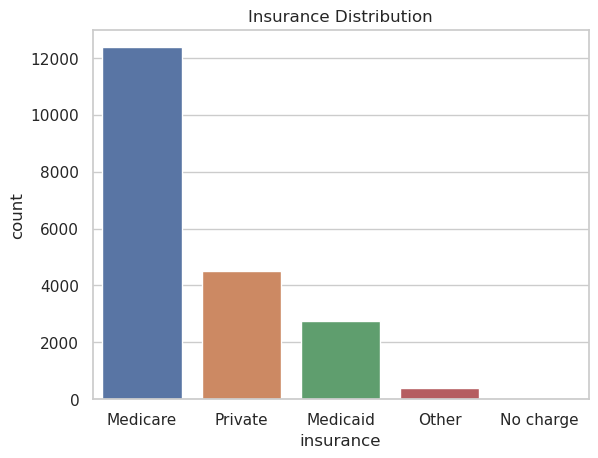

In [178]:
sns.countplot(data=df, x='insurance')
plt.title("Insurance Distribution")
plt.show()

### Diagnoses (?)


In [85]:
# top_diagnoses = df["diagnosis"].value_counts().head(10)
top_diagnoses = df.drop_duplicates(subset=["subject_id", "icd_codes"])["icd_codes"].value_counts().head(10)
top_diagnoses.plot(kind="barh")
plt.title("Top 10 Diabetes-related Diagnoses")
plt.xlabel("Number of Patients")
plt.gca().invert_yaxis()
plt.show()
# print(top_diagnoses)
# SELECT 
#     diagnosis,
#     COUNT(DISTINCT subject_id) AS num_patients
# FROM 
#     `um-thesis.cohort_diabetes.diabetes_patient_data`
# GROUP BY 
#     diagnosis
# ORDER BY 
#     num_patients DESC;

KeyError: Index(['icd_codes'], dtype='object')

### Deads
 If the individual survived for at least one year after their last hospital discharge, then the dod column will have a NULL value.

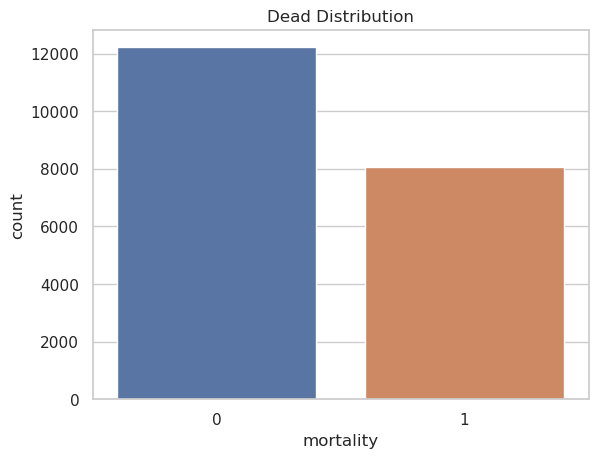

In [179]:
sns.countplot(data=df, x='mortality')
plt.title("Dead Distribution")
plt.show()

### Laboratory test

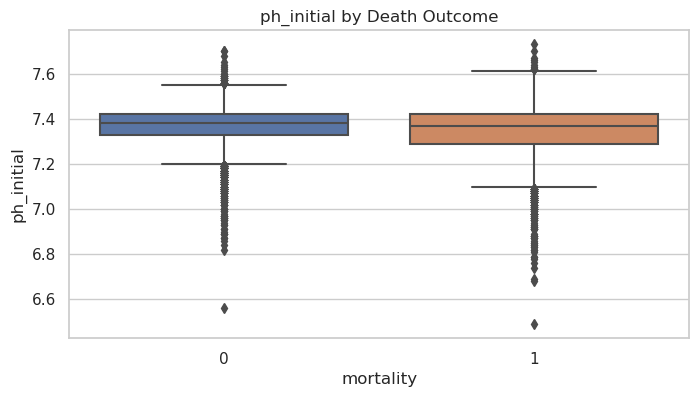

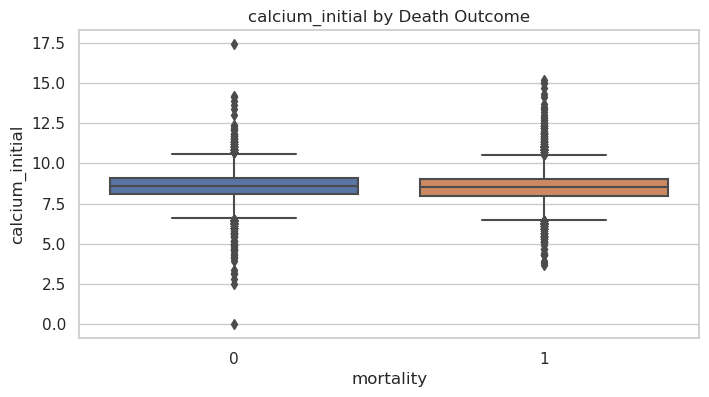

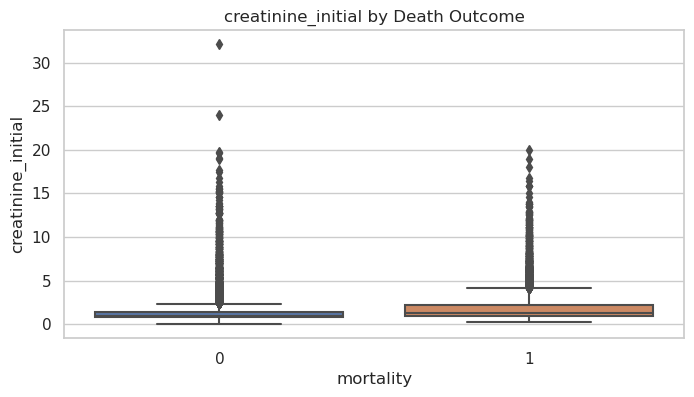

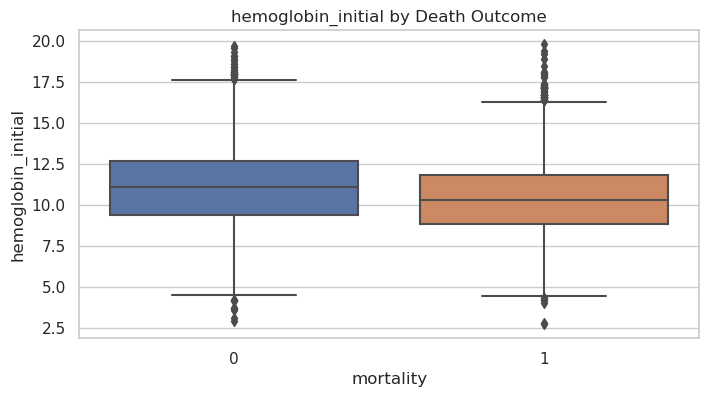

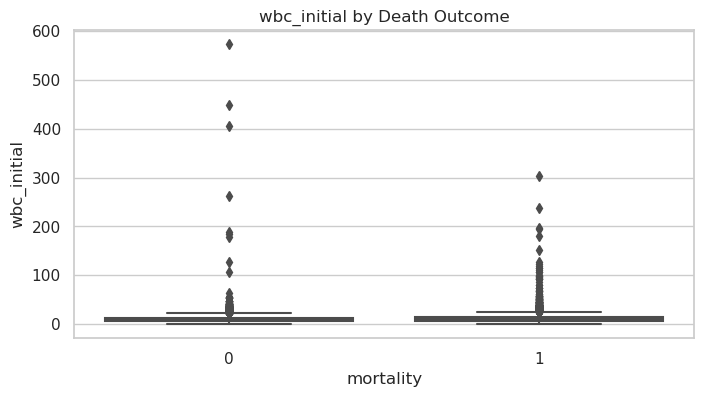

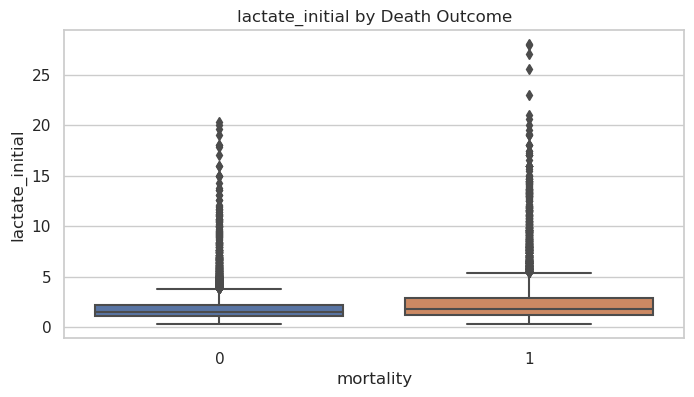

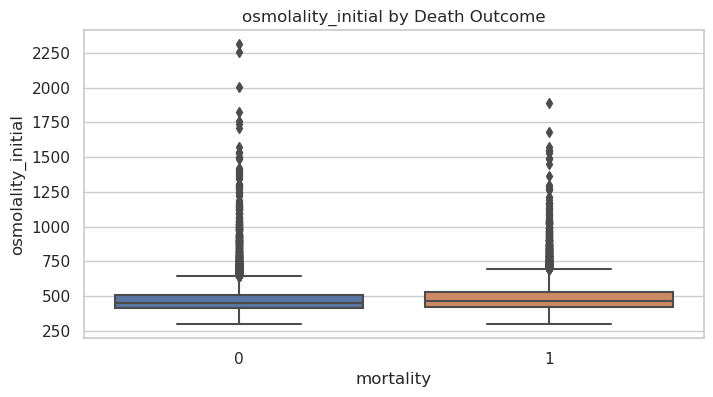

In [181]:
lab_features = [
    'ph_initial', 'calcium_initial', 'creatinine_initial',
    'hemoglobin_initial', 'wbc_initial', 'lactate_initial', 'osmolality_initial'
]

for feature in lab_features:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df, x='mortality', y=feature)
    plt.title(f'{feature} by Death Outcome')
    plt.show()




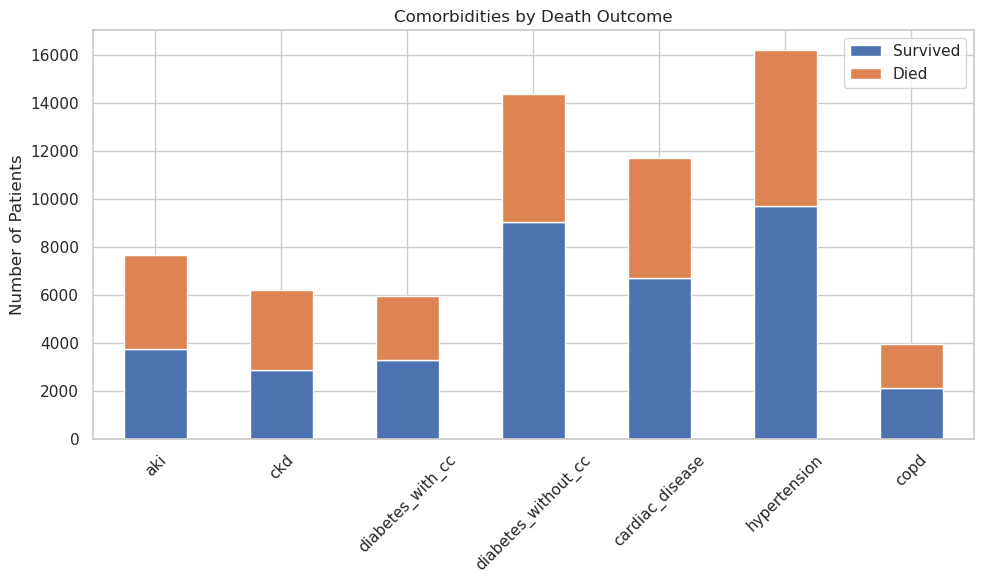

In [182]:
comorbidities = [
    'aki', 'ckd', 'diabetes_with_cc',
    'diabetes_without_cc', 'cardiac_disease', 'hypertension', 'copd'
]

comorbidity_counts = df.groupby('mortality')[comorbidities].sum().T
comorbidity_counts.columns = ['Survived', 'Died']
comorbidity_counts.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Comorbidities by Death Outcome')
plt.ylabel('Number of Patients')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [183]:
from tableone import TableOne, load_dataset
import pandas as pd

In [211]:


numerical = [
    'age', 'weight', 'ph_initial', 'calcium_initial', 'creatinine_initial',
    'hemoglobin_initial', 'wbc_initial', 'lactate_initial', 'platelet_initial',
    'potassium_initial', 'sodium_initial', 'glucose_initial', 'chloride_initial',
    'bun_initial', 'initial_heart_rate', 'initial_mbp', 'initial_resp_rate',
    'urineoutput', 'apsiii', 'sofa', 'gcs'
]

categorical = [
    'gender', 'race', 'admission_type', 'insurance', 'ventilation', 'nitroprusside',
    'vasopressor', 'albumin', 'aki', 'ckd', 'diabetes_with_cc', 'diabetes_without_cc',
    'cardiac_disease', 'hypertension', 'copd'
]

columns = numerical + categorical
groupby = 'mortality'

limit = {
    'gender': {'M': 'Male'},
    'race': {'WHITE': 'White'},
    'admission_type': {'EMERGENCY': 'Admission, emergency'},
    'insurance': {'Medicare': 'Insurance', 'Medicaid': 'Insurance', 'Other': 'Insurance'}
}

rename = {
        'age': 'Age (years)',
        'weight': 'Weight (kg)',
        'mortality': 'Mortality',
        
    }

label = {
    'age': 'Age (year)',
    'gender': 'Male (%)',
    'race': 'White (%)',
    'initial_heart_rate': 'Heartrate (bpm)',
    'heart_rate_max': 'Heartrate_max (bpm)',
    'initial_mbp': 'MAP (mmHg)',
    'initial_resp_rate': 'Respiratory_rate (insp/min)',
    'resp_rate_max': 'Respiratoryrate_max (insp/min)',
    'urineoutput': 'Urineoutput (ml)',
    'apsiii': 'APS III score',
    'sofa': 'SOFA score',
    'gcs': 'GCS score',
    'cns': 'CNS score',
    'renal': 'Renal score',
    'weight': 'Weight (kg)',
    'admission_type': 'Admission, emergency (%)',
    'insurance': 'Insurance (%)',
    'ventilation': 'Ventilation (%)',
    'nitroprusside': 'Nitrate pune (%)',
    'vasopressor': 'Vasopressor (%)',
    'albumin': 'Albumin (%)',
    'aki': 'AKI (%)',
    'ckd': 'CKD (%)',
    'cardiac_disease': 'Cardiac disease (%)',
    'hypertension': 'Hypertension (%)',
    'copd': 'COPD (%)',
    'lactate_max': 'Lactate_max (mmol/L)',
    'creatinine_initial': 'Scr (mg/dL)',
    'creatinine_max': 'Scr_max (mg/dL)',
    'ph_initial': 'PH',
    'ph_min': 'PH_min',
    'glucose_initial': 'Glucose (mg/dL)',
    'glucose_max': 'Glucose_max (mg/dL)',
    'sodium_initial': 'Sodium (mEq/L)',
    'sodium_max': 'Sodium_max (mEq/L)',
    'potassium_initial': 'Potassium (mEq/L)',
    'potassium_max': 'Potassium_max (mEq/L)',
    'calcium_initial': 'Calcium (mg/dL)',
    'chloride_initial': 'Chloride (mEq/L)',
    'wbc_initial': 'WBC (K/uL)',
    'wbc_max': 'WBC_max (K/uL)',
    'platelet_initial': 'PLT (K/uL)',
    'platelet_min': 'PLT_min (K/uL)',
    'bun_max': 'BUN_max (mg/dL)',
    'osmolality_initial': 'osmolarity',
    'osmolality_max': 'osmolarity_max',
    'osmolality_min': 'osmolarity_min',
    'diabetes': 'Diabetes (%)'
}

limit = {
    'gender': {'M': 'Male'},
    'race': {'WHITE': 'White'},
    'admission_type': {'EMERGENCY': 'Admission, emergency'},
    'insurance': {'Medicare': 'Insurance', 'Medicaid': 'Insurance', 'Other': 'Insurance'},
    'diabetes': {1: 'Diabetes'}
}

nonnormal = [
    'initial_heart_rate', 'heart_rate_max', 'initial_mbp', 'initial_resp_rate',
    'resp_rate_max', 'urineoutput', 'apsiii', 'sofa', 'gcs', 'cns', 'renal',
    'weight', 'lactate_max', 'creatinine_initial', 'creatinine_max', 'ph_initial',
    'ph_min', 'glucose_initial', 'glucose_max', 'sodium_initial', 'sodium_max',
    'potassium_initial', 'potassium_max', 'calcium_initial', 'chloride_initial',
    'wbc_initial', 'wbc_max', 'platelet_initial', 'platelet_min', 'bun_max',
    'osmolality_initial', 'osmolality_max', 'osmolality_min'
]
# Create the TableOne object
table = TableOne(
    data=df,
    columns=columns,
    categorical=categorical_vars,
    continuous=numerical_vars,
    groupby=groupby,
    pval=True,
    missing=False,
    rename=label,
    # limit=limit,
    nonnormal=nonnormal,
)


print(table.tabulate(tablefmt="fancy_grid"))

# # Get the formatted table as a dataframe
# table_df = table.tableone.reset_index()

# # Calculate total counts for title
# total_n = len(df)
# survivors_n = df[df['mortality'] == 0].shape[0]
# nonsurvivors_n = df[df['mortality'] == 1].shape[0]

# # You can rename the columns for display purposes:
# table_df.rename(columns={
#     'index': 'Characteristic',
#     0: f'Total (n = {total_n})',
#     '0': f'Survivors (n = {survivors_n})',
#     '1': f'Non-survivors (n = {nonsurvivors_n})',
#     'pval': 'p-value'
# }, inplace=True)

# table_df

╒═════════════════════════════════════════════╤═══════════════════════════════════════════╤═══════════════════════╤════════════════════════╤═══════════════════════╤═══════════╕
│                                             │                                           │ Overall               │ 0                      │ 1                     │ P-Value   │
╞═════════════════════════════════════════════╪═══════════════════════════════════════════╪═══════════════════════╪════════════════════════╪═══════════════════════╪═══════════╡
│ n                                           │                                           │ 19775                 │ 11963                  │ 7812                  │           │
├─────────────────────────────────────────────┼───────────────────────────────────────────┼───────────────────────┼────────────────────────┼───────────────────────┼───────────┤
│ Age (year), mean (SD)                       │                                           │ 67.8 (13.9)           │

In [189]:
print(table.tabulate(tablefmt  = "github"))

|                               |                                           | Overall         | 0               | 1               | P-Value   |
|-------------------------------|-------------------------------------------|-----------------|-----------------|-----------------|-----------|
| n                             |                                           | 20283           | 12219           | 8064            |           |
| Age (years), mean (SD)        |                                           | 67.8 (13.9)     | 65.0 (14.0)     | 71.9 (12.6)     | <0.001    |
| Weight (kg), mean (SD)        |                                           | 87.3 (27.0)     | 89.9 (27.3)     | 83.3 (26.0)     | <0.001    |
| ph_initial, mean (SD)         |                                           | 7.4 (0.1)       | 7.4 (0.1)       | 7.3 (0.1)       | <0.001    |
| calcium_initial, mean (SD)    |                                           | 8.5 (0.8)       | 8.6 (0.8)       | 8.5 (0.9)       | 0.00

In [212]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 19775 entries, 0 to 20282
Data columns (total 88 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   subject_id           19775 non-null  Int64         
 1   hadm_id              19775 non-null  Int64         
 2   stay_id              19775 non-null  Int64         
 3   icu_intime           19775 non-null  datetime64[us]
 4   admittime            19775 non-null  datetime64[us]
 5   dischtime            19775 non-null  datetime64[us]
 6   admission_type       19775 non-null  object        
 7   insurance            19775 non-null  object        
 8   race                 19775 non-null  object        
 9   gender               19775 non-null  object        
 10  age                  19775 non-null  Int64         
 11  weight               19775 non-null  float64       
 12  all_icd_codes        19775 non-null  object        
 13  admission_count      19775 non-null 

## MICE Imputation 
ph_* and lactate_* > 28% of missing values; urineoutput and calcium_* ~ 4%; weight ~ 2%; insurance ~1%; hemoglobin_*, platelet_*, wbc_*, osmolality_*, glucose_*, chloride_*, potassium_*, sodium_*, bun_*, creatinine_*, cns, gcs, resp_rate_max, mbp_max, renal, heart_rate_max, initial_mbp, initial_resp_rate, initial_heart_rate, cardiac_disease, ckd, aki, copd, hypertension < 1%

Features to impute with MICE: 
ph, lactate, urineoutput, calcium, weight, hemoglobin, platelet, wbc, osmolality, glucose, chloride, potassium, sodium, bun, creatinine, cns, gcs, resp_rate_max, mbp_max, renal, heart_rate_max, initial_mbp, initial_resp_rate, initial_heart_rate, cardiac_disease, ckd, aki, copd, hypertension.
Not MICE: 
Insurance

In [272]:
df_impute = df.copy()
cols_to_impute = pc_missing.index.tolist()
exclude_cols = [col for col in df_impute.columns if col not in cols_to_impute]

In [270]:
import miceforest as mf

In [273]:
# Preparation of the dataframe to apply mice
# Remove datetime times and icd_codes
df_impute = df_impute.drop(columns=['icu_intime', 'admittime', 'dischtime', 'all_icd_codes'])
# Assing category
categorical_col = ['admission_type', 'race', 'gender', 'insurance']
binary_col = ['aki', 'cardiac_disease', 'ckd', 'copd', 'hypertension']
for var in categorical_col + binary_col:
    if var in df.columns:
        df_impute[var] = df_impute[var].astype('category')
print(df_impute.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20283 entries, 0 to 20282
Data columns (total 75 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   subject_id           20283 non-null  Int64   
 1   hadm_id              20283 non-null  Int64   
 2   stay_id              20283 non-null  Int64   
 3   admission_type       20283 non-null  category
 4   insurance            20059 non-null  category
 5   race                 20283 non-null  category
 6   gender               20283 non-null  category
 7   age                  20283 non-null  Int64   
 8   weight               19837 non-null  float64 
 9   admission_count      20283 non-null  Int64   
 10  icu_stay_count       20283 non-null  Int64   
 11  aki                  20280 non-null  category
 12  ckd                  20280 non-null  category
 13  diabetes_with_cc     20283 non-null  Int64   
 14  diabetes_without_cc  20283 non-null  Int64   
 15  cardiac_disease    

In [280]:

high_missing = pc_missing[pc_missing>15].index.tolist()
print(high_missing)
 # missing[missing > 0]
variable_schema = {}

['ph_max', 'ph_initial', 'ph_min', 'lactate_min', 'lactate_initial', 'lactate_max']


In [281]:
ph_cols = ['ph_initial', 'ph_min', 'ph_max']
lactate_cols = ['lactate_initial', 'lactate_min', 'lactate_max']

variable_schema = {}
for col in high_missing:
    if col.startswith('ph_'):
        variable_schema[col] = [c for c in df_impute.columns if not c.startswith('lactate_') and c != col]
    if col.startswith('lactate_'):
        variable_schema[col] = [c for c in df_impute.columns if not c.startswith('ph_') and c != col]

print(variable_schema)    
    

{'ph_max': ['subject_id', 'hadm_id', 'stay_id', 'admission_type', 'insurance', 'race', 'gender', 'age', 'weight', 'admission_count', 'icu_stay_count', 'aki', 'ckd', 'diabetes_with_cc', 'diabetes_without_cc', 'cardiac_disease', 'hypertension', 'copd', 'ph_initial', 'ph_min', 'calcium_initial', 'calcium_min', 'calcium_max', 'creatinine_initial', 'creatinine_min', 'creatinine_max', 'hemoglobin_initial', 'hemoglobin_min', 'hemoglobin_max', 'wbc_initial', 'wbc_min', 'wbc_max', 'platelet_initial', 'platelet_min', 'platelet_max', 'potassium_initial', 'potassium_min', 'potassium_max', 'sodium_initial', 'sodium_min', 'sodium_max', 'glucose_initial', 'glucose_min', 'glucose_max', 'chloride_initial', 'chloride_min', 'chloride_max', 'bun_initial', 'bun_min', 'bun_max', 'osmolality_initial', 'osmolality_min', 'osmolality_max', 'initial_heart_rate', 'heart_rate_max', 'initial_mbp', 'mbp_max', 'initial_resp_rate', 'resp_rate_max', 'urineoutput', 'apsiii', 'apsiii_prob', 'sofa', 'cns', 'renal', 'gcs',

In [278]:
print(df_impute.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20283 entries, 0 to 20282
Data columns (total 75 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   subject_id           20283 non-null  Int64   
 1   hadm_id              20283 non-null  Int64   
 2   stay_id              20283 non-null  Int64   
 3   admission_type       20283 non-null  category
 4   insurance            20059 non-null  category
 5   race                 20283 non-null  category
 6   gender               20283 non-null  category
 7   age                  20283 non-null  Int64   
 8   weight               19837 non-null  float64 
 9   admission_count      20283 non-null  Int64   
 10  icu_stay_count       20283 non-null  Int64   
 11  aki                  20280 non-null  category
 12  ckd                  20280 non-null  category
 13  diabetes_with_cc     20283 non-null  Int64   
 14  diabetes_without_cc  20283 non-null  Int64   
 15  cardiac_disease    

In [282]:
kernel = mf.ImputationKernel(
    df_impute,
    num_datasets=30,
    random_state=42,
    variable_schema=variable_schema
)
    

In [ ]:
kernel.mice(iterations=5)

In [ ]:
df_imputed = kernel.complete_data(0)